# Tarea 3 - Exploración y análisis de datos

## Pregunta de negocio 2 — Distribución territorial de los recursos

**Rol:** Análisis de datos
**Integrante:** Cristian Camilo Rodríguez Cagueñas

**Pregunta:**

> ¿Dónde ejecuta INVIAS sus recursos? Dado que el SECOP II no registra el lugar
> de ejecución del contrato, ¿qué proporción de la contratación es
> territorialmente identificable a partir del objeto contractual, y cómo se
> distribuyen y evolucionan en el territorio los recursos que sí lo son?

### Preguntas específicas

1. ¿Qué proporción de los contratos y del valor es territorialmente identificable,
   y cómo ha evolucionado esa trazabilidad en el tiempo?
2. ¿Qué departamentos concentran el mayor valor contratado?
3. ¿Cómo se comporta esa distribución a lo largo del tiempo y según el tipo de
   contrato y la modalidad?
4. ¿En qué se diferencia la contratación territorializable de la asociada a la
   operación central?

### Insumo

`Tarea 2/Pregunta 2/df_analitico_p2.csv`, la base construida en la Tarea 2:
25.605 contratos con las variables territoriales inferidas del objeto contractual.

In [1]:
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

## 1. Preparación

Se replican los criterios de la Tarea 2: se trabaja con los contratos que tienen
valor contractual registrado y se excluyen los que superan un billón de pesos,
identificados en la auditoría como registros que requieren validación de calidad
de datos antes de entrar en agregaciones.

In [2]:
df = pd.read_csv("../../Tarea 2/Pregunta 2/df_analitico_p2.csv", low_memory=False)
df["fecha_de_firma"] = pd.to_datetime(df["fecha_de_firma"], errors="coerce", utc=True)

UMBRAL_VALOR_ATIPICO = 1e12

dfv = df[
    df["valor_del_contrato"].notna()
    & (df["valor_del_contrato"] > 0)
    & (df["valor_del_contrato"] < UMBRAL_VALOR_ATIPICO)
].copy()

print(f"Contratos en la base           : {len(df):,}".replace(",", "."))
print(f"Con valor contractual valido   : {len(dfv):,}".replace(",", "."))
print(f"Excluidos por valor atipico    : {(df['valor_del_contrato'] >= UMBRAL_VALOR_ATIPICO).sum()}")

Contratos en la base           : 25.605
Con valor contractual valido   : 19.617
Excluidos por valor atipico    : 15


In [3]:
# Paleta del proyecto. Los colores y su orden provienen de una paleta validada
# para daltonismo; se usan siempre en el mismo orden y nunca de forma ciclica.
AZUL     = "#2a78d6"
NARANJA  = "#eb6834"
AQUA     = "#1baf7a"
TINTA    = "#0b0b0b"
GRIS     = "#52514e"
GRIS_SUAVE = "#898781"
LINEA    = "#e1e0d9"

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "font.size": 9,
    "axes.edgecolor": LINEA,
    "axes.labelcolor": GRIS,
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.titlecolor": TINTA,
    "xtick.color": GRIS_SUAVE,
    "ytick.color": GRIS_SUAVE,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})


def limpiar_ejes(ax, quitar_y=False):
    ax.grid(axis="x" if quitar_y else "y", color=LINEA, linewidth=0.7)
    ax.set_axisbelow(True)
    if quitar_y:
        ax.spines["left"].set_visible(False)

## 2. Trazabilidad territorial

La primera pregunta específica es cuánta de la contratación puede ubicarse en el
territorio. Es el punto de partida: define sobre qué universo se puede hacer un
análisis geográfico y cuánto queda fuera.

In [4]:
cobertura = dfv.groupby("trazabilidad_territorial").agg(
    contratos=("id_contrato", "size"),
    valor=("valor_del_contrato", "sum"),
)
cobertura["%_contratos"] = (100 * cobertura["contratos"] / cobertura["contratos"].sum()).round(1)
cobertura["valor_billones"] = (cobertura["valor"] / 1e12).round(2)
cobertura["%_valor"] = (100 * cobertura["valor"] / cobertura["valor"].sum()).round(1)

cobertura[["contratos", "%_contratos", "valor_billones", "%_valor"]]

,contratos,%_contratos,valor_billones,%_valor
trazabilidad_territorial,,,,
Departamento único,8029,40.9,19.99,51.1
Multidepartamental,457,2.3,10.50,26.8
No territorializable,11131,56.7,8.64,22.1


### 2.1 La cobertura en contratos y en valor no coinciden

El contraste entre ambas medidas es el primer hallazgo del análisis.

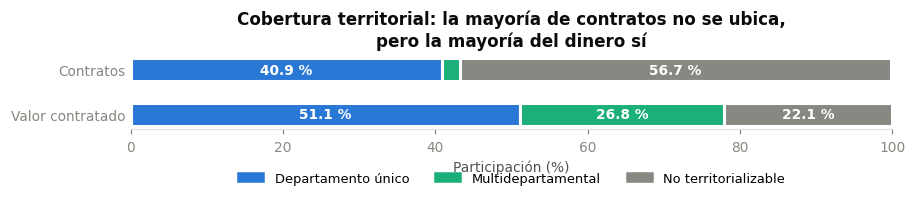

In [5]:
orden = ["Departamento único", "Multidepartamental", "No territorializable"]
colores = [AZUL, AQUA, GRIS_SUAVE]

fig, ax = plt.subplots(figsize=(8.4, 2.4))

for i, (medida, etiqueta) in enumerate([("%_contratos", "Contratos"), ("%_valor", "Valor contratado")]):
    izquierda = 0
    for categoria, color in zip(orden, colores):
        ancho = cobertura.loc[categoria, medida]
        ax.barh(etiqueta, ancho, left=izquierda, color=color, height=0.52,
                edgecolor="white", linewidth=2)
        if ancho > 6:
            ax.text(izquierda + ancho / 2, i, f"{ancho:.1f} %", ha="center", va="center",
                    color="white", fontsize=9, fontweight="semibold")
        izquierda += ancho

ax.set_xlim(0, 100)
ax.set_xlabel("Participación (%)")
ax.set_title("Cobertura territorial: la mayoría de contratos no se ubica,\npero la mayoría del dinero sí")
ax.invert_yaxis()
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

manijas = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colores]
ax.legend(manijas, orden, loc="upper center", bbox_to_anchor=(0.5, -0.42),
          ncol=3, frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

**Hallazgo 1.** Solo el 43 % de los contratos puede ubicarse en el territorio,
pero ese 43 % concentra el **78 % del valor contratado**. La contratación que no
se puede ubicar es numerosa pero pequeña en monto.

### 2.2 Qué hay en la contratación que no se puede ubicar

Antes de aceptar esa cobertura conviene entender qué queda fuera. Si los
contratos sin territorio fueran una muestra aleatoria, el análisis geográfico
estaría sesgado; si responden a una naturaleza distinta, la cobertura parcial es
una característica de la entidad y no un defecto del método.

In [6]:
comparacion = dfv.assign(
    grupo=np.where(dfv["es_territorializable"], "Territorializable", "No territorializable")
)

composicion = pd.crosstab(
    comparacion["tipo_de_contrato"], comparacion["grupo"], normalize="columns"
).mul(100).round(1)
composicion["diferencia"] = (composicion["No territorializable"] - composicion["Territorializable"]).round(1)
composicion.sort_values("diferencia", ascending=False).head(8)

grupo,No territorializable,Territorializable,diferencia
tipo_de_contrato,,,
Prestación de servicios,84.1,23.9,60.2
Suministros,3.4,2.5,0.9
Compraventa,0.7,0.0,0.7
Seguros,0.3,0.0,0.3
Concesión,0.0,0.0,0.0
Comodato,0.0,0.0,0.0
Arrendamiento de muebles,0.0,0.0,0.0
Servicios financieros,0.0,0.0,0.0


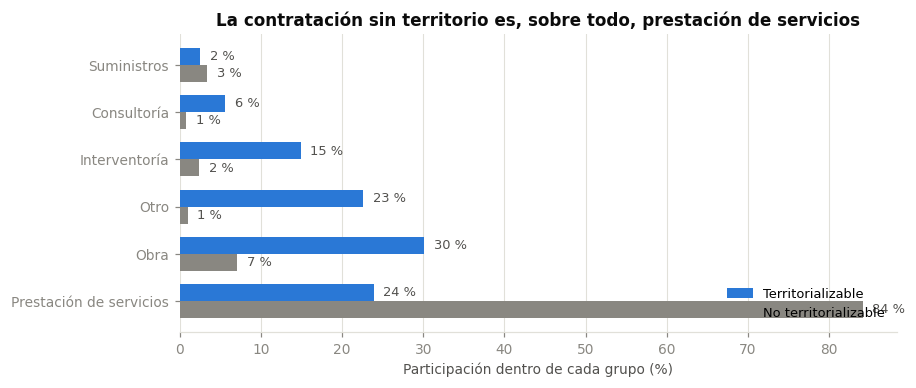

In [7]:
principales = (composicion.drop(columns="diferencia")
               .assign(total=lambda d: d.sum(axis=1))
               .sort_values("total", ascending=False)
               .head(6)
               .drop(columns="total"))

fig, ax = plt.subplots(figsize=(8.4, 3.6))
y = np.arange(len(principales))
alto = 0.36

ax.barh(y + alto/2, principales["Territorializable"], alto, color=AZUL, label="Territorializable")
ax.barh(y - alto/2, principales["No territorializable"], alto, color=GRIS_SUAVE, label="No territorializable")

for i, (t, nt) in enumerate(zip(principales["Territorializable"], principales["No territorializable"])):
    ax.text(t + 1.2, i + alto/2, f"{t:.0f} %", va="center", fontsize=8.5, color=GRIS)
    ax.text(nt + 1.2, i - alto/2, f"{nt:.0f} %", va="center", fontsize=8.5, color=GRIS)

ax.set_yticks(y, principales.index)
ax.set_xlabel("Participación dentro de cada grupo (%)")
ax.set_title("La contratación sin territorio es, sobre todo, prestación de servicios")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
limpiar_ejes(ax, quitar_y=True)
plt.tight_layout()
plt.show()

### 2.3 Prueba de independencia

Se contrasta formalmente si la trazabilidad territorial es independiente del tipo
de contrato.

- **H₀:** la trazabilidad territorial y el tipo de contrato son independientes.
- **H₁:** existe asociación entre ambas variables.

In [8]:
tabla = pd.crosstab(comparacion["tipo_de_contrato"], comparacion["grupo"])
chi2, p_valor, gl, _ = stats.chi2_contingency(tabla)

n = tabla.values.sum()
v_cramer = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

print(f"Chi-cuadrado      : {chi2:.1f}")
print(f"Grados de libertad: {gl}")
print(f"Valor p           : {'< 1e-300' if p_valor == 0 else f'{p_valor:.3g}'}")
print(f"V de Cramer       : {v_cramer:.3f}")
print()
print("Se rechaza la independencia." if p_valor < 0.05 else "No se rechaza la independencia.")

Chi-cuadrado      : 8149.3
Grados de libertad: 14
Valor p           : < 1e-300
V de Cramer       : 0.645

Se rechaza la independencia.


La asociación es muy significativa y de magnitud considerable. La ausencia de
información territorial **no es aleatoria**: se concentra en la contratación de
apoyo a la operación central, que por su naturaleza no está ligada a una vía.

Esto respalda la decisión metodológica de la Tarea 2: la cobertura parcial
describe cómo contrata la entidad y no una falla de registro.

### 2.4 Evolución de la trazabilidad en el tiempo

¿El registro del territorio ha mejorado o empeorado? La pregunta importa para el
usuario: es una medida de la calidad de la información pública disponible.

In [9]:
traza_anual = dfv.groupby("anio_firma").apply(
    lambda g: pd.Series({
        "contratos": len(g),
        "pct_contratos": round(100 * g["es_territorializable"].mean(), 1),
        "pct_valor": round(100 * g.loc[g["es_territorializable"], "valor_del_contrato"].sum()
                           / g["valor_del_contrato"].sum(), 1),
    }), include_groups=False
)
traza_anual

,contratos,pct_contratos,pct_valor
anio_firma,,,
2017.0,47.0,46.8,28.8
2018.0,1070.0,37.6,94.1
2019.0,1253.0,55.1,73.4
2020.0,2037.0,46.8,85.3
2021.0,2019.0,41.3,94.7
2022.0,1504.0,38.3,93.1
2023.0,3871.0,50.7,76.0
2024.0,2952.0,58.0,76.3
2025.0,1613.0,27.6,46.3


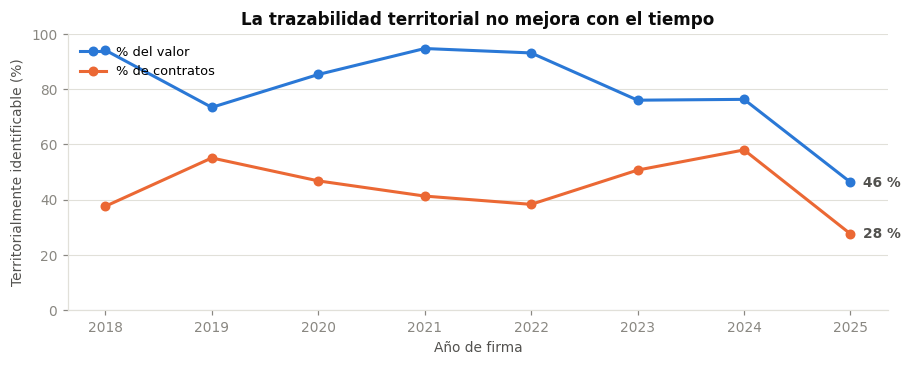

In [10]:
# 2017 y 2026 son anios parciales; se excluyen de la lectura de tendencia
serie = traza_anual.loc[2018:2025]

fig, ax = plt.subplots(figsize=(8.4, 3.4))
ax.plot(serie.index, serie["pct_valor"], color=AZUL, linewidth=2,
        marker="o", markersize=5.5, label="% del valor")
ax.plot(serie.index, serie["pct_contratos"], color=NARANJA, linewidth=2,
        marker="o", markersize=5.5, label="% de contratos")

for x, y in [(serie.index[-1], serie["pct_valor"].iloc[-1]),
             (serie.index[-1], serie["pct_contratos"].iloc[-1])]:
    ax.annotate(f"{y:.0f} %", (x, y), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=9, color=GRIS, fontweight="semibold")

ax.set_ylim(0, 100)
ax.set_xlabel("Año de firma")
ax.set_ylabel("Territorialmente identificable (%)")
ax.set_title("La trazabilidad territorial no mejora con el tiempo")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

In [11]:
rho, p_rho = stats.spearmanr(serie.index, serie["pct_valor"])
print(f"Correlacion de Spearman entre anio y % del valor trazable: rho = {rho:.3f}, p = {p_rho:.3f}")
print("Tendencia monotona significativa." if p_rho < 0.05 else
      "Sin tendencia monotona significativa: la trazabilidad oscila sin mejorar ni deteriorarse.")

Correlacion de Spearman entre anio y % del valor trazable: rho = -0.476, p = 0.233
Sin tendencia monotona significativa: la trazabilidad oscila sin mejorar ni deteriorarse.


**Hallazgo 2.** Entre 2018 y 2025 la proporción del valor territorialmente
identificable oscila sin una tendencia clara. Nueve años después, la entidad
sigue sin registrar el lugar de ejecución de forma estructurada: la trazabilidad
depende de que el objeto contractual mencione el territorio, lo cual varía año a
año sin mejorar.

## 3. Distribución territorial de los recursos

El análisis se restringe a los contratos con atribución inequívoca a un
departamento. Los multidepartamentales se excluyen de los rankings porque
replicarlos duplicaría el valor.

In [12]:
unico = dfv[dfv["trazabilidad_territorial"] == "Departamento único"].copy()

por_depto = unico.groupby("departamento_inferido").agg(
    contratos=("id_contrato", "size"),
    valor=("valor_del_contrato", "sum"),
    valor_mediano=("valor_del_contrato", "median"),
)
por_depto["%_valor"] = (100 * por_depto["valor"] / por_depto["valor"].sum()).round(1)
por_depto["valor_mm"] = (por_depto["valor"] / 1e9).round(0)
por_depto = por_depto.sort_values("valor", ascending=False)

print(f"Contratos analizados: {len(unico):,}".replace(",", "."))
print(f"Valor total         : ${unico['valor_del_contrato'].sum()/1e12:.2f} billones".replace(".", ","))
por_depto[["contratos", "valor_mm", "%_valor", "valor_mediano"]].head(12)

Contratos analizados: 8.029
Valor total         : $19,99 billones


,contratos,valor_mm,%_valor,valor_mediano
departamento_inferido,,,,
Antioquia,475,2565.0,12.8,2.017462e+08
Nariño,482,2149.0,10.7,2.013776e+08
Cauca,465,2026.0,10.1,2.012882e+08
Putumayo,210,1476.0,7.4,1.995060e+08
Norte de Santander,387,1295.0,6.5,1.997740e+08
Boyacá,521,1153.0,5.8,2.430981e+08
Córdoba,427,979.0,4.9,2.110000e+08
Santander,418,973.0,4.9,2.009193e+08
Tolima,334,819.0,4.1,1.994912e+08


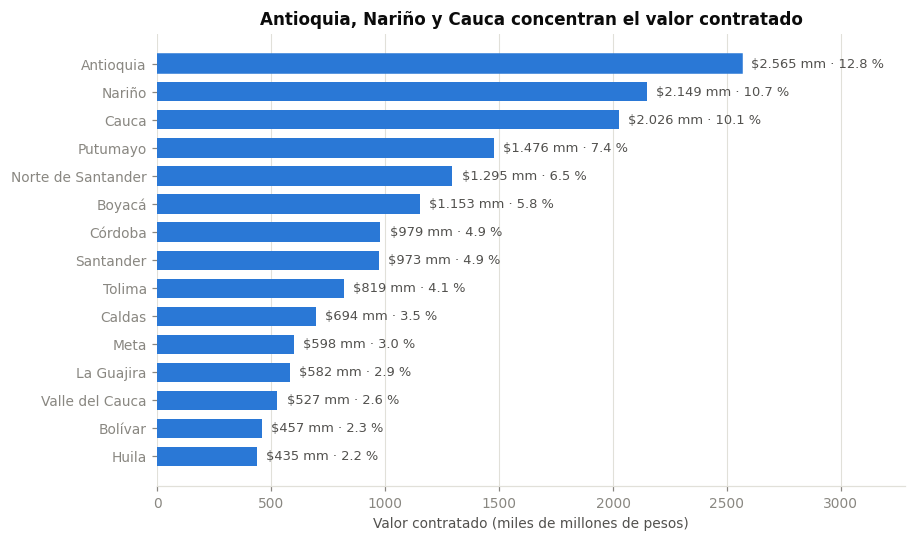

In [13]:
top = por_depto.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8.4, 5))
barras = ax.barh(top.index, top["valor_mm"], color=AZUL, height=0.68)
barras[-1].set_color(AZUL)

for nombre, valor, pct in zip(top.index, top["valor_mm"], top["%_valor"]):
    ax.text(valor + 40, nombre, f"${valor:,.0f} mm · {pct:.1f} %".replace(",", "."),
            va="center", fontsize=8.5, color=GRIS)

ax.set_xlim(0, top["valor_mm"].max() * 1.28)
ax.set_xlabel("Valor contratado (miles de millones de pesos)")
ax.set_title("Antioquia, Nariño y Cauca concentran el valor contratado")
limpiar_ejes(ax, quitar_y=True)
plt.tight_layout()
plt.show()

### 3.1 Concentración

Se mide qué tan concentrada está la distribución territorial con la curva
acumulada y el índice de Herfindahl-Hirschman.

In [14]:
acum = por_depto["valor"].cumsum() / por_depto["valor"].sum() * 100
participaciones = por_depto["%_valor"] / 100
hhi = (participaciones ** 2).sum()

print(f"Departamentos que concentran el 50 % del valor: {(acum <= 50).sum() + 1}")
print(f"Departamentos que concentran el 80 % del valor: {(acum <= 80).sum() + 1}")
print(f"Indice HHI: {hhi:.3f}  (1/33 = {1/33:.3f} seria reparto uniforme)")

Departamentos que concentran el 50 % del valor: 6
Departamentos que concentran el 80 % del valor: 14
Indice HHI: 0.064  (1/33 = 0.030 seria reparto uniforme)


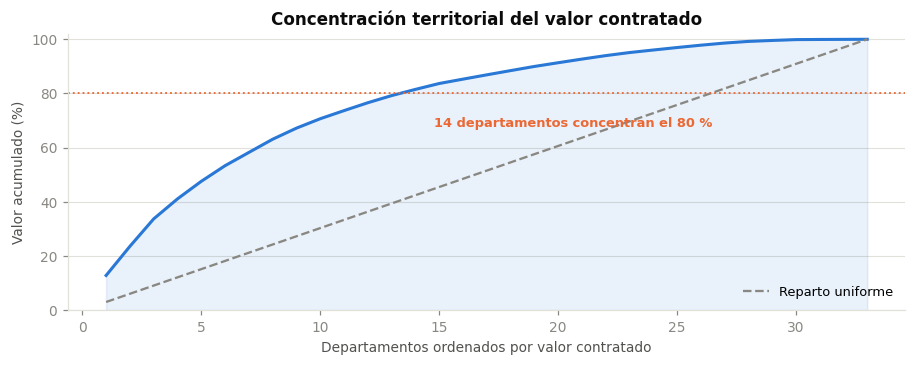

In [15]:
fig, ax = plt.subplots(figsize=(8.4, 3.4))
x = np.arange(1, len(acum) + 1)
ax.plot(x, acum.values, color=AZUL, linewidth=2)
ax.fill_between(x, acum.values, color=AZUL, alpha=0.10)
ax.plot(x, x / len(acum) * 100, color=GRIS_SUAVE, linewidth=1.5,
        linestyle="--", label="Reparto uniforme")

n80 = (acum <= 80).sum() + 1
ax.axhline(80, color=NARANJA, linewidth=1.2, linestyle=":")
ax.annotate(f"{n80} departamentos concentran el 80 %",
            (n80, 80), xytext=(12, -22), textcoords="offset points",
            fontsize=8.5, color=NARANJA, fontweight="semibold")

ax.set_xlabel("Departamentos ordenados por valor contratado")
ax.set_ylabel("Valor acumulado (%)")
ax.set_title("Concentración territorial del valor contratado")
ax.set_ylim(0, 102)
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

### 3.2 Mapa

La distribución en el mapa permite ver si la concentración responde a un patrón
regional.

In [16]:
EQUIVALENCIA_GEOJSON = {
    "Amazonas": "AMAZONAS", "Antioquia": "ANTIOQUIA", "Arauca": "ARAUCA",
    "Atlántico": "ATLANTICO", "Bolívar": "BOLIVAR", "Boyacá": "BOYACA",
    "Caldas": "CALDAS", "Caquetá": "CAQUETA", "Casanare": "CASANARE",
    "Cauca": "CAUCA", "Cesar": "CESAR", "Chocó": "CHOCO", "Córdoba": "CORDOBA",
    "Cundinamarca": "CUNDINAMARCA", "Guainía": "GUAINIA", "Guaviare": "GUAVIARE",
    "Huila": "HUILA", "La Guajira": "LA GUAJIRA", "Magdalena": "MAGDALENA",
    "Meta": "META", "Nariño": "NARIÑO", "Norte de Santander": "NORTE DE SANTANDER",
    "Putumayo": "PUTUMAYO", "Quindío": "QUINDIO", "Risaralda": "RISARALDA",
    "San Andrés y Providencia": "ARCHIPIELAGO DE SAN ANDRES PROVIDENCIA Y SANTA CATALINA",
    "Santander": "SANTANDER", "Sucre": "SUCRE", "Tolima": "TOLIMA",
    "Valle del Cauca": "VALLE DEL CAUCA", "Vaupés": "VAUPES", "Vichada": "VICHADA",
    "Bogotá D.C.": "SANTAFE DE BOGOTA D.C",
}

mapa = gpd.read_file("../../despliegue/data/departamentos_colombia.geojson")
valores = por_depto.reset_index().assign(
    NOMBRE_DPT=lambda d: d["departamento_inferido"].map(EQUIVALENCIA_GEOJSON))
mapa = mapa.merge(valores, on="NOMBRE_DPT", how="left")

print("Departamentos sin datos en el mapa:", mapa["valor_mm"].isna().sum())

Departamentos sin datos en el mapa: 0


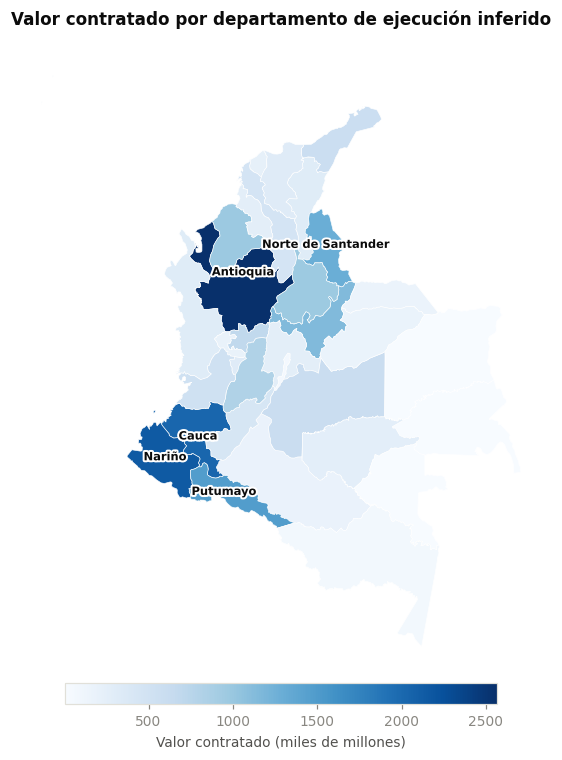

In [17]:
fig, ax = plt.subplots(figsize=(6.6, 7.4))
mapa.plot(column="valor_mm", cmap="Blues", linewidth=0.4, edgecolor="white",
          ax=ax, legend=True, missing_kwds={"color": "#f0efe9", "edgecolor": "white"},
          legend_kwds={"label": "Valor contratado (miles de millones)",
                       "orientation": "horizontal", "shrink": 0.62, "pad": 0.01})

# Halo blanco para que la etiqueta se lea sobre cualquier tono del mapa
from matplotlib import patheffects

for _, fila in mapa.nlargest(5, "valor_mm").iterrows():
    punto = fila.geometry.representative_point()
    ax.annotate(fila["departamento_inferido"], (punto.x, punto.y), ha="center",
                fontsize=7.5, color=TINTA, fontweight="semibold",
                path_effects=[patheffects.withStroke(linewidth=2.6, foreground="white")])

ax.set_axis_off()
ax.set_title("Valor contratado por departamento de ejecución inferido", pad=14)
plt.tight_layout()
plt.show()

**Hallazgo 3.** La contratación no se concentra en el centro económico del país
sino en departamentos de periferia y de topografía difícil — Nariño, Cauca,
Putumayo, Chocó — junto con Antioquia. Es coherente con la misión del INVIAS: la
red vial nacional no concesionada, que es la que atraviesa las zonas donde no hay
operador privado.

### 3.3 Volumen frente a tamaño de contrato

Un mismo valor total puede venir de muchos contratos pequeños o de pocos grandes.
La distinción importa para el seguimiento.

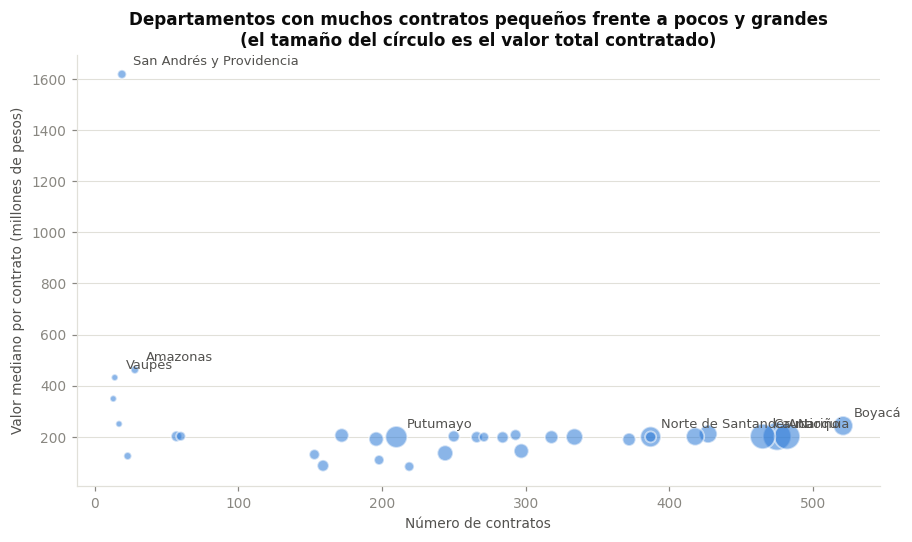

In [18]:
fig, ax = plt.subplots(figsize=(8.4, 5))
ax.scatter(por_depto["contratos"], por_depto["valor_mediano"] / 1e6,
           s=por_depto["valor_mm"] / 8 + 18, color=AZUL, alpha=0.55,
           edgecolor="white", linewidth=1.2)

destacar = por_depto.nlargest(6, "valor").index.union(por_depto.nlargest(3, "valor_mediano").index)
for nombre in destacar:
    fila = por_depto.loc[nombre]
    ax.annotate(nombre, (fila["contratos"], fila["valor_mediano"] / 1e6),
                xytext=(7, 6), textcoords="offset points", fontsize=8.5, color=GRIS)

ax.set_xlabel("Número de contratos")
ax.set_ylabel("Valor mediano por contrato (millones de pesos)")
ax.set_title("Departamentos con muchos contratos pequeños frente a pocos y grandes\n"
             "(el tamaño del círculo es el valor total contratado)")
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

### 3.4 Prueba sobre las diferencias entre departamentos

Se contrasta si el valor de los contratos difiere entre departamentos. Se usa
Kruskal-Wallis porque la distribución del valor contractual es fuertemente
asimétrica y no cumple los supuestos de ANOVA.

- **H₀:** la distribución del valor contractual es la misma en todos los departamentos.
- **H₁:** al menos un departamento difiere.

In [19]:
grupos = [g["valor_del_contrato"].values
          for _, g in unico.groupby("departamento_inferido") if len(g) >= 30]

h, p_kw = stats.kruskal(*grupos)
print(f"Departamentos comparados (>= 30 contratos): {len(grupos)}")
print(f"Estadistico H : {h:.1f}")
print(f"Valor p       : {p_kw:.3g}")
print()
print("Se rechaza la igualdad de distribuciones." if p_kw < 0.05
      else "No se rechaza la igualdad de distribuciones.")

Departamentos comparados (>= 30 contratos): 27
Estadistico H : 208.7
Valor p       : 1.91e-30

Se rechaza la igualdad de distribuciones.


## 4. Evolución territorial en el tiempo

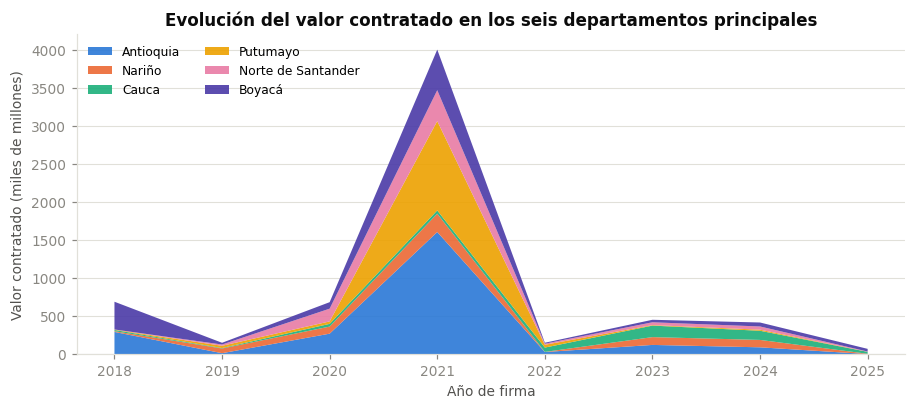

In [20]:
top6 = por_depto.head(6).index.tolist()
evol = (unico[unico["departamento_inferido"].isin(top6) & unico["anio_firma"].between(2018, 2025)]
        .groupby(["anio_firma", "departamento_inferido"])["valor_del_contrato"].sum()
        .unstack(fill_value=0) / 1e9)

fig, ax = plt.subplots(figsize=(8.4, 3.8))
ax.stackplot(evol.index, evol[top6].T.values, labels=top6,
             colors=[AZUL, NARANJA, AQUA, "#eda100", "#e87ba4", "#4a3aa7"], alpha=0.9)
ax.set_xlabel("Año de firma")
ax.set_ylabel("Valor contratado (miles de millones)")
ax.set_title("Evolución del valor contratado en los seis departamentos principales")
ax.legend(frameon=False, fontsize=8, loc="upper left", ncol=2)
limpiar_ejes(ax)
plt.tight_layout()
plt.show()

## 5. Departamento, tipo de contrato y modalidad

In [21]:
top10 = por_depto.head(10).index.tolist()
tipos_principales = unico["tipo_de_contrato"].value_counts().head(5).index.tolist()

matriz = pd.crosstab(
    unico.loc[unico["departamento_inferido"].isin(top10), "departamento_inferido"],
    unico.loc[unico["departamento_inferido"].isin(top10), "tipo_de_contrato"],
    values=unico.loc[unico["departamento_inferido"].isin(top10), "valor_del_contrato"],
    aggfunc="sum", normalize="index",
).mul(100)[tipos_principales].reindex(top10).round(1)

matriz

tipo_de_contrato,Obra,Prestación de servicios,Otro,Interventoría,Consultoría
departamento_inferido,,,,,
Antioquia,58.5,0.7,34.9,5.0,0.8
Nariño,81.2,1.1,10.2,5.0,2.4
Cauca,89.0,2.4,3.6,2.9,2.1
Putumayo,96.1,0.3,1.7,0.8,0.9
Norte de Santander,76.8,1.4,14.7,4.6,2.4
Boyacá,49.6,2.4,36.6,7.8,3.5
Córdoba,39.7,1.4,49.4,6.5,2.7
Santander,39.5,2.8,45.7,10.1,1.9
Tolima,58.4,0.8,36.5,3.1,1.1


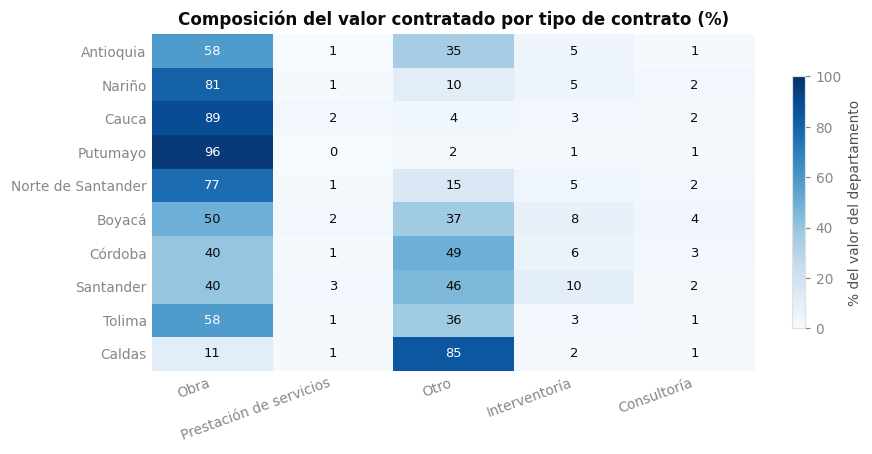

In [22]:
fig, ax = plt.subplots(figsize=(8.4, 4.2))
im = ax.imshow(matriz.values, cmap="Blues", aspect="auto", vmin=0, vmax=100)

ax.set_xticks(range(len(matriz.columns)), matriz.columns, rotation=20, ha="right")
ax.set_yticks(range(len(matriz.index)), matriz.index)

for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        v = matriz.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8.5,
                    color="white" if v > 55 else TINTA)

ax.set_title("Composición del valor contratado por tipo de contrato (%)")
for borde in ax.spines.values():
    borde.set_visible(False)
ax.tick_params(length=0)
plt.colorbar(im, ax=ax, shrink=0.75, label="% del valor del departamento")
plt.tight_layout()
plt.show()

**Hallazgo 4.** La composición varía de forma marcada entre departamentos: en unos
el valor está dominado por contratos de obra y en otros por interventoría o
prestación de servicios. Un ranking por valor total, leído solo, esconde que no
todos los departamentos reciben el mismo tipo de intervención.

## 6. Síntesis de hallazgos

**1. La trazabilidad territorial es parcial pero cubre la mayor parte de los recursos.**
El 43 % de los contratos puede ubicarse en el territorio y concentra el 78 % del
valor contratado. La contratación que no se puede ubicar es numerosa y de bajo monto.

**2. Lo que no se puede ubicar tiene una naturaleza distinta.** La prueba de
chi-cuadrado rechaza la independencia entre trazabilidad y tipo de contrato: los
contratos sin territorio son mayoritariamente prestación de servicios de apoyo a
la operación central. La cobertura parcial describe cómo contrata la entidad, no
un defecto del método.

**3. La trazabilidad no mejora con el tiempo.** Entre 2018 y 2025 la proporción del
valor identificable oscila sin tendencia significativa. Nueve años de datos
después, el lugar de ejecución sigue sin registrarse de forma estructurada.

**4. Los recursos se concentran en la periferia, no en el centro económico.**
Antioquia, Nariño, Cauca y Putumayo encabezan el valor contratado, coherente con
la misión del INVIAS sobre la red vial no concesionada.

**5. La concentración es alta pero no extrema.** Un grupo reducido de departamentos
acumula el 80 % del valor, con un HHI muy por encima del reparto uniforme.

**6. El tipo de intervención varía por departamento.** El valor está dominado por
obra en unos y por interventoría o servicios en otros, lo que matiza la lectura
del ranking.

### Implicación para el usuario

Para la Dirección y los organismos de control, el resultado tiene dos lecturas.
La primera es dónde se ejecutan los recursos, con el detalle por departamento y
por año. La segunda, menos evidente y más accionable: **uno de cada cinco pesos
no es rastreable territorialmente desde la información publicada en el SECOP II**.
Registrar el lugar de ejecución en la fuente resolvería esa limitación de raíz.

**Siguiente paso:** diseño y desarrollo del tablero (Tarea 4).